In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
PROTEIN, MIN_POS, MAX_POS = 'RT', 39, 226

ALL_SEQ = functions.read_seq(str(data_root / "RT" / "data" / "rt.reduce4.seq"))
with open(str(data_root / "RT" / "data" / "rt.consensus.reduce4.seq")) as f:
    CONSENSUS = f.read().strip()
REDUX = functions.get_redu_dict(str(data_root / "RT" / "data" / "rt.reduce4.redux"), 0)


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


J = build_J_matrix(str(data_root / "RT" / "data" / "J_RT.npy"), MIN_POS, MAX_POS)
L = MAX_POS - MIN_POS + 1
print(f"{PROTEIN}: {len(ALL_SEQ):,} sequences, {L} positions")

RT: 19,194 sequences, 188 positions


In [2]:
# ---------------------------------------------------------------------------
# Where the range of dE double comes from, term by term.
#
# For a pair (p1: wt1->mt1, p2: wt2->mt2), dE double splits EXACTLY into one term per
# background position q, plus the direct p1-p2 coupling:
#
#     dE double = sum_{q not in {p1,p2}} c(q)  +  [J(p1,p2,wt1,wt2) - J(p1,p2,mt1,mt2)]
#     c(q)      = [J(p1,q,wt1,s_q) - J(p1,q,mt1,s_q)] + [J(p2,q,wt2,s_q) - J(p2,q,mt2,s_q)]
#
# Every term is a DIFFERENCE of J values, and the only thing that changes from sequence to
# sequence is s_q, the residue the background happens to carry at q. So each position q can
# take just four values -- one per residue A/B/C/D -- and how much q moves dE double depends
# on two things:
#
#     lever   how far apart those four values are (a property of J alone)
#     usage   how often the alignment actually visits the residues that differ
#
# A position with a big lever that is never mutated contributes nothing to the range; a
# position that varies a lot but whose four J differences are equal contributes nothing
# either. Both have to be non-trivial, which is what CVAL and FREQ below separate.
# ---------------------------------------------------------------------------
_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def reduced_idx(pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(REDUX, a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(REDUX, b))
    return (pos1 - MIN_POS, pos2 - MIN_POS, "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def decompose(pair, codes, onehot):
    """Per-position J-difference terms for one pair.

    Returns
        C      (N, L)  c(q) for every sequence and position -- the realized terms
        CVAL   (L, 4)  the four values c(q) can take, one per residue at q  (J only)
        de     (N,)    dE double, rebuilt from the terms and checked against the direct route
        direct scalar  the p1-p2 coupling difference, the one term with no background in it
    """
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(pair)
    qs = np.arange(L)

    CVAL = ((J[p1][qs[:, None], wt1, np.arange(4)[None, :]]
             - J[p1][qs[:, None], mt1, np.arange(4)[None, :]])
            + (J[p2][qs[:, None], wt2, np.arange(4)[None, :]]
               - J[p2][qs[:, None], mt2, np.arange(4)[None, :]])).astype(np.float64)
    CVAL[[p1, p2]] = 0.0                      # the pair's own positions carry no background term

    C = CVAL[qs[None, :], codes]              # (N, L) realized terms
    direct = float(J[p1, p2, wt1, wt2] - J[p1, p2, mt1, mt2])

    S1 = _site_energies(onehot, J, p1, (p1, p2))
    S2 = _site_energies(onehot, J, p2, (p1, p2))
    J12 = J[p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    de = M[:, wt1, wt2] - M[:, mt1, mt2]
    assert np.allclose(C.sum(axis=1) + direct, de, atol=1e-3), pair
    return C, CVAL, de, direct


print("machinery ready")

machinery ready


In [3]:
# =============================================================================
# Rank the top-dde DRM pairs by their dE double RANGE, then keep the extremes.
#
# top_20_DRM.txt holds the top-20 dde double pairs for each RT drug class (NRTI first, then
# NNRTI). For every pair that the model can handle we rebuild dE double over the whole
# alignment and measure its range the same way the earlier probe did -- 95th minus 5th
# percentile, which ignores a handful of outlier sequences.
#
# The question this notebook asks is the one the probe left open: a wide-range pair and a
# narrow-range pair are supposed to differ in HOW MANY background positions have leverage on
# them and WHERE those positions sit. So we take the 5 widest and the 5 narrowest and put
# their per-position sd profiles side by side, rows sorted by range.
# =============================================================================
N_EACH = 5
DRM_FILE = data_root / "RT" / "data" / "top_20_DRM.txt"

raw_pairs = []
for line in DRM_FILE.read_text().splitlines():
    line = line.strip()
    if line:
        raw_pairs.append('-'.join(tok.strip() for tok in line.split('-')))

CODES, ONEHOT = encode_seqs(ALL_SEQ, MIN_POS, MAX_POS)
POSITIONS = np.arange(MIN_POS, MAX_POS + 1)

STATS, skipped = {}, []
for pair in raw_pairs:
    try:
        p1, p2, *_ = reduced_idx(pair)
        if not (0 <= p1 < L and 0 <= p2 < L):
            raise ValueError(f"position outside {MIN_POS}-{MAX_POS}")
        C, CVAL, de, direct = decompose(pair, CODES, ONEHOT)
        lo, hi = np.percentile(de, [5, 95])
        STATS[pair] = dict(sd_q=C.std(axis=0), de=de, rng=hi - lo,
                           self_pos=(p1, p2), direct=direct)
    except Exception as exc:
        skipped.append((pair, str(exc)))

RANKED = pd.DataFrame(
    [{'pair': p, 'dE double range (95-5%)': d['rng'], 'sd(dE double)': d['de'].std(),
      'mean dE double': d['de'].mean(),
      'positions with sd(c) > 0.1': int((d['sd_q'] > 0.1).sum()),
      'largest position sd': d['sd_q'].max(),
      'strongest position': POSITIONS[int(np.argmax(d['sd_q']))]}
     for p, d in STATS.items()]
).sort_values('dE double range (95-5%)', ascending=False).reset_index(drop=True)

print(f"{len(STATS)} usable pairs out of {len(raw_pairs)} lines")
if skipped:
    print("skipped:", ', '.join(f'{p} ({why})' for p, why in skipped))
RANKED.round(3)

40 usable pairs out of 40 lines


,pair,dE double range (95-5%),sd(dE double),mean dE double,positions with sd(c) > 0.1,largest position sd,strongest position
0,L210W-T215Y,19.798,6.291,-0.700,38,2.448,41
1,M41L-T215Y,17.862,5.677,0.627,39,1.895,210
2,L210W-T215S,15.296,4.914,-2.796,38,1.878,41
3,M41L-T215F,14.916,4.812,-1.168,43,1.260,210
4,M41L-T215S,14.212,4.630,-1.870,38,1.709,210
5,K70R-K219Q,13.397,3.876,-3.945,29,2.342,67
6,D67N-K219Q,12.531,3.973,-2.982,33,1.975,70
7,D67N-K219E,11.900,3.813,-3.136,31,1.990,70
8,D67N-K70R,11.366,3.629,-2.516,24,2.141,219
9,K70R-K219E,10.787,3.378,-3.808,35,2.202,67


In [4]:
# The two extremes. WIDE keeps its descending order and NARROW is appended still descending,
# so the whole figure reads top-to-bottom as "most background-sensitive -> least".
WIDE = list(RANKED['pair'][:N_EACH])
NARROW = list(RANKED['pair'][-N_EACH:])
PAIRS = WIDE + NARROW
GROUP = {**{p: 'widest dE double range' for p in WIDE},
         **{p: 'narrowest dE double range' for p in NARROW}}

RNG = np.array([STATS[p]['rng'] for p in PAIRS])
SD = np.stack([STATS[p]['sd_q'] for p in PAIRS])
SD_TABLE = pd.DataFrame(SD, index=PAIRS, columns=POSITIONS)

for p in PAIRS:
    print(f"{GROUP[p]:<26} {p:<14} range {STATS[p]['rng']:6.2f}   "
          f"{int((STATS[p]['sd_q'] > 0.1).sum()):3d} positions with sd(c) > 0.1")

widest dE double range     L210W-T215Y    range  19.80    38 positions with sd(c) > 0.1
widest dE double range     M41L-T215Y     range  17.86    39 positions with sd(c) > 0.1
widest dE double range     L210W-T215S    range  15.30    38 positions with sd(c) > 0.1
widest dE double range     M41L-T215F     range  14.92    43 positions with sd(c) > 0.1
widest dE double range     M41L-T215S     range  14.21    38 positions with sd(c) > 0.1
narrowest dE double range  L100I-K103R    range   4.71    28 positions with sd(c) > 0.1
narrowest dE double range  A62V-V75I      range   4.67    27 positions with sd(c) > 0.1
narrowest dE double range  K101P-D192N    range   4.46    21 positions with sd(c) > 0.1
narrowest dE double range  V75I-F77L      range   4.38    23 positions with sd(c) > 0.1
narrowest dE double range  V75I-I132L     range   4.31    24 positions with sd(c) > 0.1


In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})

# Sequential, one hue, light -> dark: sd of c(q) is a magnitude, so darker red = a background
# position that swings this pair's dE double harder.
REDS = LinearSegmentedColormap.from_list(
    'jterm_reds', ['#fcfcfb', '#fbdcd0', '#f4a582', '#e2604a', '#bf2321', '#6d0f18'])
REDS.set_bad('#eeedea')          # the pair's own two positions carry no background term


def bare(ax, grid='y'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax

print('style ready')

style ready


In [6]:
# =============================================================================
# FITNESS = -E, where E is the Potts statistical energy of the whole sequence.
#
# This project's energy is coupling-only -- utilities.functions.calculate_e sums J over every
# position pair and there is no separate field term, the fields having been absorbed into J
# by the gauge the model was fit in:
#
#     E(s) = sum_{i<j} J(i, j, s_i, s_j)
#
# and its delta_e is written E(wt) - E(mt), so a mutation with positive dE LOWERS the energy.
# Lower statistical energy means more prevalent in the alignment means fitter, so throughout
# this notebook
#
#     fitness(s) = -E(s)      and     "better" means strictly lower E.
#
# The assertion below ties this back to the machinery the earlier notebooks used: the energy
# difference between consensus and a double mutant built on consensus must equal the dE
# double that decompose() reports for the consensus sequence.
# =============================================================================
IDX = np.arange(L)

def energy(codes):
    """Total Potts energy of one full-length sequence given as residue codes (L,)."""
    return float(0.5 * J[IDX[:, None], IDX[None, :], codes[:, None], codes[None, :]].sum())

CONS_CODES, CONS_ONEHOT = encode_seqs([CONSENSUS], MIN_POS, MAX_POS)
CONS = CONS_CODES[0].astype(np.int64)
FREQ = np.stack([(CODES == a).mean(axis=0) for a in range(4)], axis=1)      # (L, 4) usage

_probe = 'L210W-T215Y'
_p1, _p2, _wt1, _mt1, _wt2, _mt2 = reduced_idx(_probe)
_dbl = CONS.copy()
_dbl[_p1], _dbl[_p2] = _mt1, _mt2
_ref = CONS.copy()
_ref[_p1], _ref[_p2] = _wt1, _wt2
_de_cons = decompose(_probe, CONS_CODES, CONS_ONEHOT)[2][0]
assert abs((energy(_ref) - energy(_dbl)) - _de_cons) < 1e-3, "energy() disagrees with decompose()"

print(f"energy() checked against decompose() on {_probe}:  dE double = {_de_cons:.3f}")
print(f"consensus E = {energy(CONS):.2f}")

energy() checked against decompose() on L210W-T215Y:  dE double = -5.547
consensus E = -874.59


In [7]:
# =============================================================================
# THE ACCESSIBLE MUTATIONAL NETWORK -- everything grows outward from the double mutant.
#
# No pre-chosen locus set and no coarse-graining. The space is the real one:
#
#   ROOT          the double mutant on an otherwise consensus sequence
#   A MOVE        change ONE position to ONE other residue -- every position in the model
#                 except the pair's own two, and every one of the 3 residues it is not
#                 currently carrying.  186 positions x 3 residues = 558 candidate moves,
#                 re-evaluated from scratch at every node
#   IRREVERSIBLE  the double mutation is locked, and once a position has been mutated it is
#                 locked too: nothing ever goes back
#   UPHILL ONLY   a move becomes an edge only if it strictly lowers E, i.e. makes the
#                 sequence fitter
#
# The network is then everything reachable from the double mutant under those rules, grown
# breadth-first until no node has a move left. Every node therefore carries the double
# mutation and is descended from it -- the root points outward, and nothing points back.
#
# A node with no outgoing edge is a DEAD END (red): every one of its 558 candidate moves
# makes things worse, and nothing can be undone.
# =============================================================================
import networkx as nx

def dm_base(pair):
    """Consensus with the pair's two mutations written in -- the locked starting sequence."""
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(pair)
    base = CONS.copy()
    base[p1], base[p2] = mt1, mt2
    return base, (p1, p2)


def delta_matrix(seq):
    """(L, 4): energy change for switching position q to residue a.  0 at the current residue."""
    S = np.zeros((L, 4))
    for a in range(4):
        S[:, a] = J[:, :, a, :][:, IDX, seq].sum(axis=1)
    return S - S[IDX, seq][:, None]


def accessible_network(pair):
    """Grow every strictly-improving, irreversible path outward from the double mutant."""
    base, (p1, p2) = dm_base(pair)
    root = frozenset()
    seqs = {root: base.copy()}
    E = {root: energy(base)}
    Gr = nx.DiGraph()
    Gr.add_node(root)
    depth = {root: 0}
    n_candidates = 0

    frontier = [root]
    while frontier:
        nxt = []
        for state in frontier:
            seq = seqs[state]
            D = delta_matrix(seq)
            allowed = np.ones((L, 4), dtype=bool)
            allowed[IDX, seq] = False                 # not a move: already that residue
            allowed[[p1, p2], :] = False              # the double mutation is locked
            for q, _ in state:
                allowed[q, :] = False                 # already mutated: cannot change again
            n_candidates += int(allowed.sum())

            for q, a in np.argwhere((D < 0) & allowed):
                q, a = int(q), int(a)
                child = frozenset(state | {(q, a)})
                if child not in seqs:
                    s2 = seq.copy()
                    s2[q] = a
                    seqs[child] = s2
                    E[child] = E[state] + D[q, a]
                    depth[child] = depth[state] + 1
                    nxt.append(child)
                Gr.add_edge(state, child, dE=float(D[q, a]))
        frontier = nxt

    return dict(graph=Gr, E=E, depth=depth, root=root, seqs=seqs,
                n_candidates=n_candidates,
                dead=[n for n in Gr if Gr.out_degree(n) == 0])


def state_label(state):
    return '+'.join(f"{POSITIONS[q]}{'ABCD'[a]}" for q, a in sorted(state)) or 'DM'


NET = {}
for pair in PAIRS:
    NET[pair] = accessible_network(pair)

print(f"{'pair':<14}{'group':<9}{'nodes':>6}{'edges':>6}{'dead':>6}{'depth':>6}"
      f"{'moves tested':>14}{'  E(DM)':>10}{'  E(best)':>10}")
for pair in PAIRS:
    d = NET[pair]
    Gr = d['graph']
    best = min(d['E'], key=d['E'].get)
    print(f"{pair:<14}{'widest' if GROUP[pair].startswith('widest') else 'narrowest':<9}"
          f"{Gr.number_of_nodes():>6}{Gr.number_of_edges():>6}{len(d['dead']):>6}"
          f"{max(d['depth'].values()):>6}{d['n_candidates']:>14}"
          f"{d['E'][d['root']]:>10.2f}{d['E'][best]:>10.2f}")
print(f"\n558 candidate moves are tested at every node "
      f"(186 positions x 3 residues); E(consensus) = {energy(CONS):.2f}")

pair          group     nodes edges  dead depth  moves tested     E(DM)   E(best)
L210W-T215Y   widest        8    10     2     3          4428   -869.05   -871.15
M41L-T215Y    widest        2     1     1     1          1113   -871.26   -871.30
L210W-T215S   widest        8    11     1     3          4428   -867.67   -868.70
M41L-T215F    widest        2     1     1     1          1113   -869.07   -869.19
M41L-T215S    widest        2     1     1     1          1113   -869.14   -869.23
L100I-K103R   narrowest     2     1     1     1          1113   -866.22   -866.29
A62V-V75I     narrowest     1     0     1     0           558   -867.74   -867.74
K101P-D192N   narrowest     2     1     1     1          1113   -864.06   -864.34
V75I-F77L     narrowest     2     1     1     1          1113   -866.11   -866.14
V75I-I132L    narrowest     1     0     1     0           558   -865.44   -865.44

558 candidate moves are tested at every node (186 positions x 3 residues); E(consensus) = -874.59

saved fitness_graphs_RT_wide_vs_narrow.png / .pdf


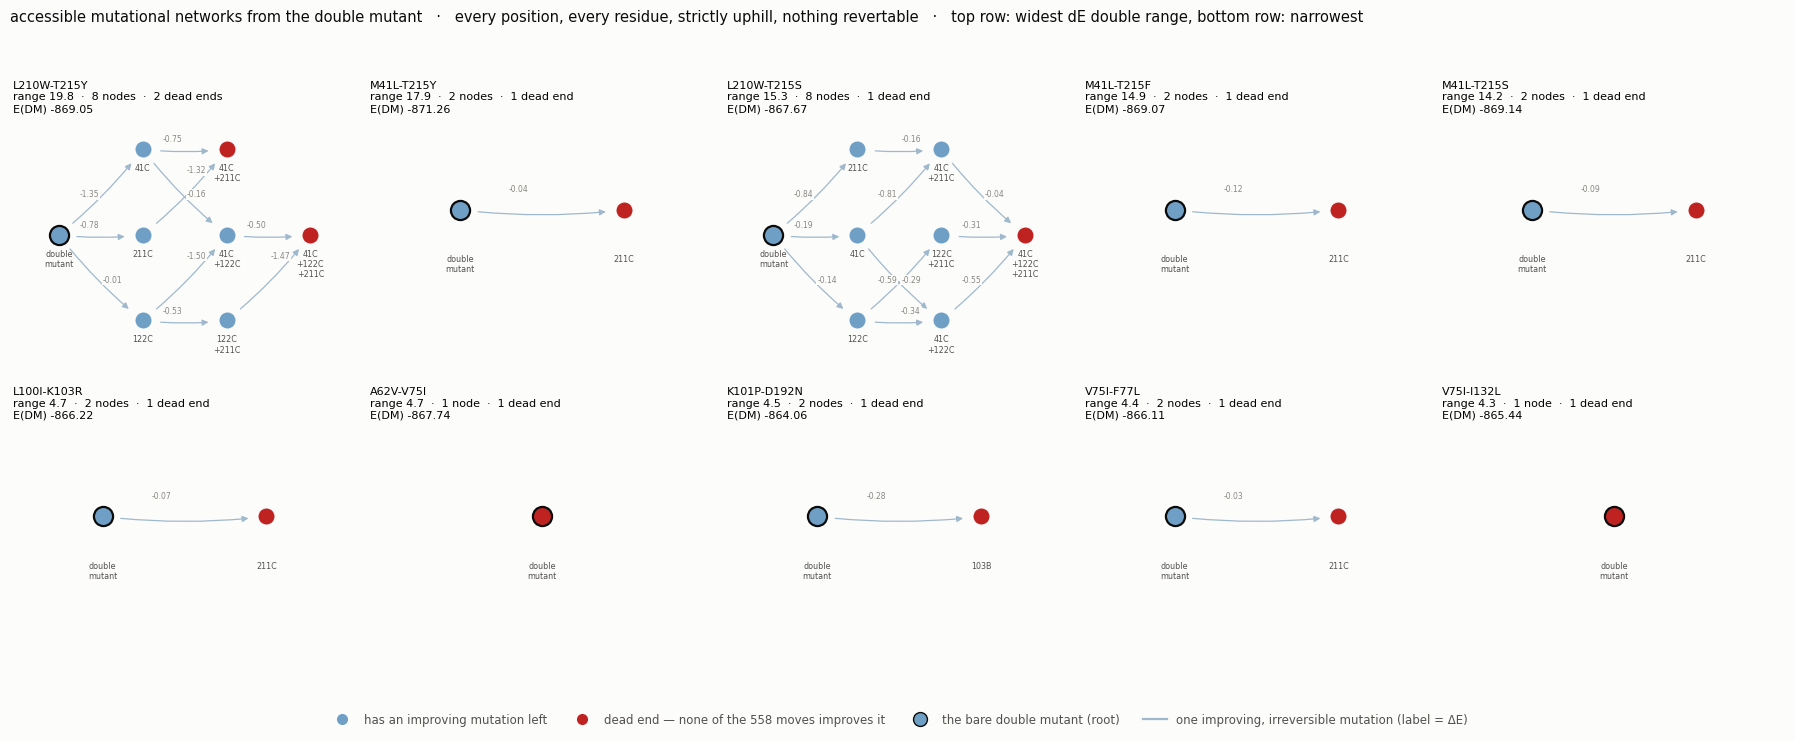

In [8]:
# =============================================================================
# THE FIGURE -- node-link graphs in the style of Fig. 2b/2c, with no axes at all.
#
# Each panel is the whole accessible network of one pair. The root, ringed, is the bare
# double mutant; every arrow is one strictly-improving irreversible mutation, labelled with
# the energy it buys; and position on the page carries no quantity -- it is a graph drawing,
# not a plot. Nodes are laid out by how many mutations have accumulated, left to right, so
# the drawing reads outward from the double mutant the way the walk does.
#
#   red node    DEAD END -- all 558 candidate moves make it worse, nothing is revertable
#   blue node   still has an improving mutation available
# =============================================================================
DEADC, LIVEC, EDGEC = '#bf2321', '#6f9fc4', '#9fb8cc'

fig, axes = plt.subplots(2, 5, figsize=(18.0, 7.2))

for ax, pair in zip(axes.ravel(), PAIRS):
    d = NET[pair]
    Gr, E, depth, root = d['graph'], d['E'], d['depth'], d['root']

    by_depth = {}
    for n in Gr:
        by_depth.setdefault(depth[n], []).append(n)
    pos = {}
    for dep, nodes in by_depth.items():
        nodes = sorted(nodes, key=lambda n: E[n])
        ys = [0.0] if len(nodes) == 1 else list(np.linspace(1.0, -1.0, len(nodes)))
        for n, y in zip(nodes, ys):
            pos[n] = (float(dep), y)

    for ei, (u, v) in enumerate(Gr.edges()):
        ax.annotate('', xy=pos[v], xytext=pos[u],
                    arrowprops=dict(arrowstyle='-|>', mutation_scale=9, color=EDGEC,
                                    lw=0.9, shrinkA=13, shrinkB=13,
                                    connectionstyle='arc3,rad=0.06'), zorder=2)
        t = 0.36 + 0.28 * (ei % 2)              # stagger along the edge so labels do not collide
        mx = pos[u][0] + t * (pos[v][0] - pos[u][0])
        my = pos[u][1] + t * (pos[v][1] - pos[u][1])
        ax.text(mx, my + 0.06, f"{Gr[u][v]['dE']:+.2f}", fontsize=5.5, color=MUTED,
                ha='center', va='bottom', zorder=3,
                bbox=dict(facecolor=SURFACE, edgecolor='none', pad=0.6))

    for n in Gr:
        dead = Gr.out_degree(n) == 0
        ax.scatter(*pos[n], s=190 if n == root else 150,
                   color=DEADC if dead else LIVEC, edgecolor=INK if n == root else SURFACE,
                   linewidth=1.6 if n == root else 0.7, zorder=5)
        lab = 'double\nmutant' if n == root else state_label(n).replace('+', '\n+')
        ax.text(pos[n][0], pos[n][1] - 0.17, lab, fontsize=5.8, ha='center', va='top',
                color=INK2, zorder=6)

    n_dead, n_nodes = len(d['dead']), Gr.number_of_nodes()
    ax.set_title(f'{pair}\nrange {STATS[pair]["rng"]:.1f}  ·  {n_nodes} '
                 f'node{"s" if n_nodes != 1 else ""}  ·  '
                 f'{n_dead} dead end{"s" if n_dead != 1 else ""}\n'
                 f'E(DM) {E[root]:.2f}',
                 fontsize=8, loc='left', pad=6)
    ax.title.set_color('#1f77b4' if GROUP[pair] == 'widest dE double range' else '#e06a10')

    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - 0.55, max(xs) + 0.55)
    ax.set_ylim(min(ys) - 0.62, max(ys) + 0.34)      # fit the drawing, not a fixed box
    ax.axis('off')

handles = [Line2D([], [], marker='o', ls='', markerfacecolor=LIVEC, markeredgecolor=SURFACE,
                  markersize=9, label='has an improving mutation left'),
           Line2D([], [], marker='o', ls='', markerfacecolor=DEADC, markeredgecolor=SURFACE,
                  markersize=9, label='dead end — none of the 558 moves improves it'),
           Line2D([], [], marker='o', ls='', markerfacecolor=LIVEC, markeredgecolor=INK,
                  markersize=10, label='the bare double mutant (root)'),
           Line2D([], [], color=EDGEC, lw=1.6,
                  label='one improving, irreversible mutation (label = ΔE)')]
fig.legend(handles=handles, ncol=4, fontsize=8.5, labelcolor=INK2, loc='lower center',
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle('accessible mutational networks from the double mutant   ·   every position, '
             'every residue, strictly uphill, nothing revertable   ·   '
             'top row: widest dE double range, bottom row: narrowest',
             fontsize=10.5, color=INK, x=0.006, ha='left')
fig.tight_layout(rect=[0, 0.03, 1, 0.94])

fig.savefig('fitness_graphs_RT_wide_vs_narrow.png', dpi=400, bbox_inches='tight',
            pad_inches=0.04, facecolor=SURFACE)
fig.savefig('fitness_graphs_RT_wide_vs_narrow.pdf', bbox_inches='tight', pad_inches=0.04,
            facecolor=SURFACE)
print('saved fitness_graphs_RT_wide_vs_narrow.png / .pdf')
plt.show()

saved fitness_graph_comparison_RT.png


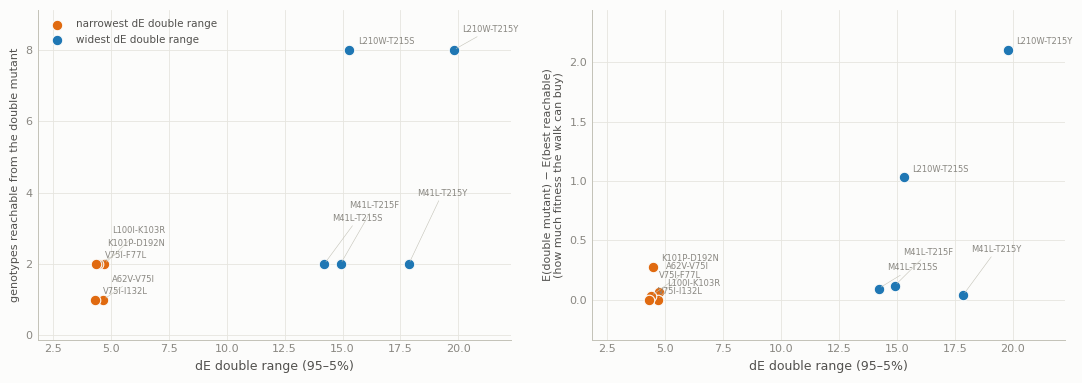

saved fitness_graph_summary_RT.csv, fitness_graph_nodes_RT.csv


,group,pairs,median_dE_range,median_improving_moves,median_nodes,median_longest_path,DM_is_dead_end,median_total_gain
0,narrowest dE double range,5,4.46,1.0,2.0,1.0,2,0.03
1,widest dE double range,5,15.30,1.0,2.0,1.0,0,0.12


,pair,group,dE double range,E(double mutant),improving moves from the DM,nodes in the network,edges,dead ends,longest path (mutations),DM is a dead end,best genotype,E(best),total gain from the DM
0,L210W-T215Y,widest dE double range,19.798,-869.046,3,8,10,2,3,False,41C+211C,-871.151,2.106
1,M41L-T215Y,widest dE double range,17.862,-871.263,1,2,1,1,1,False,211C,-871.302,0.039
2,L210W-T215S,widest dE double range,15.296,-867.667,3,8,11,1,3,False,41C+122C+211C,-868.701,1.033
3,M41L-T215F,widest dE double range,14.916,-869.073,1,2,1,1,1,False,211C,-869.192,0.119
4,M41L-T215S,widest dE double range,14.212,-869.139,1,2,1,1,1,False,211C,-869.233,0.094
5,L100I-K103R,narrowest dE double range,4.714,-866.224,1,2,1,1,1,False,211C,-866.292,0.068
6,A62V-V75I,narrowest dE double range,4.673,-867.745,0,1,0,1,0,True,DM,-867.745,0.000
7,K101P-D192N,narrowest dE double range,4.459,-864.059,1,2,1,1,1,False,103B,-864.337,0.278
8,V75I-F77L,narrowest dE double range,4.377,-866.107,1,2,1,1,1,False,211C,-866.139,0.032
9,V75I-I132L,narrowest dE double range,4.310,-865.435,0,1,0,1,0,True,DM,-865.435,0.000


In [9]:
# =============================================================================
# THE COMPARISON -- widest against narrowest dE double range.
# =============================================================================
SUMMARY = pd.DataFrame([{
    'pair': p,
    'group': GROUP[p],
    'dE double range': STATS[p]['rng'],
    'E(double mutant)': NET[p]['E'][NET[p]['root']],
    'improving moves from the DM': NET[p]['graph'].out_degree(NET[p]['root']),
    'nodes in the network': NET[p]['graph'].number_of_nodes(),
    'edges': NET[p]['graph'].number_of_edges(),
    'dead ends': len(NET[p]['dead']),
    'longest path (mutations)': max(NET[p]['depth'].values()),
    'DM is a dead end': NET[p]['graph'].out_degree(NET[p]['root']) == 0,
    'best genotype': state_label(min(NET[p]['E'], key=NET[p]['E'].get)),
    'E(best)': min(NET[p]['E'].values()),
    'total gain from the DM':
        NET[p]['E'][NET[p]['root']] - min(NET[p]['E'].values()),
} for p in PAIRS])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 3.9))
col = {'widest dE double range': '#1f77b4', 'narrowest dE double range': '#e06a10'}

for ax, ycol, ylab in (
        (a1, 'nodes in the network', 'genotypes reachable from the double mutant'),
        (a2, 'total gain from the DM',
         'E(double mutant) − E(best reachable)\n(how much fitness the walk can buy)')):
    for g, sub in SUMMARY.groupby('group'):
        ax.scatter(sub['dE double range'], sub[ycol], s=58, color=col[g], edgecolor=SURFACE,
                   linewidth=0.8, label=g, zorder=3)
    _span = float(SUMMARY[ycol].max() - SUMMARY[ycol].min()) or 1.0
    _seen = {}
    for _, r in SUMMARY.sort_values('dE double range').iterrows():
        _key = round(float(r[ycol]) / (0.055 * _span))
        _n = _seen.get(_key, 0)
        _seen[_key] = _n + 1
        ax.annotate(r['pair'], (r['dE double range'], r[ycol]), textcoords='offset points',
                    xytext=(6, 4 + 9 * _n), fontsize=6, color=MUTED,
                    arrowprops=dict(arrowstyle='-', color=BASE, lw=0.4,
                                    shrinkA=0, shrinkB=2) if _n else None)
    ax.set_xlabel('dE double range (95–5%)', color=INK2)
    ax.set_ylabel(ylab, color=INK2, fontsize=8)
    ax.margins(0.16)
    bare(ax, grid='both')
a1.legend(fontsize=7.5, labelcolor=INK2, loc='upper left')

fig.tight_layout()
fig.savefig('fitness_graph_comparison_RT.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved fitness_graph_comparison_RT.png')
plt.show()

GROUPED = SUMMARY.groupby('group').agg(
    pairs=('pair', 'size'),
    median_dE_range=('dE double range', 'median'),
    median_improving_moves=('improving moves from the DM', 'median'),
    median_nodes=('nodes in the network', 'median'),
    median_longest_path=('longest path (mutations)', 'median'),
    DM_is_dead_end=('DM is a dead end', 'sum'),
    median_total_gain=('total gain from the DM', 'median')).reset_index()

SUMMARY.to_csv('fitness_graph_summary_RT.csv', index=False)
pd.DataFrame([{'pair': p, 'genotype': state_label(n), 'E': NET[p]['E'][n],
               'mutations added': NET[p]['depth'][n],
               'is a dead end': n in NET[p]['dead'],
               'is the double mutant': n == NET[p]['root']}
              for p in PAIRS for n in NET[p]['graph']]
             ).to_csv('fitness_graph_nodes_RT.csv', index=False)
print('saved fitness_graph_summary_RT.csv, fitness_graph_nodes_RT.csv')
display(GROUPED.round(2))
SUMMARY.round(3)